# Loss visualization

### Losses vs. probe

Load tensorboard logs

In [3]:
import pandas as pd

probes = pd.read_csv("logs/general/probes_multimodal_linear.csv")
probes.rename(columns={"Value": "Probe"}, inplace=True)
probes.drop(columns=["Wall time"], inplace=True)

pred_losses = pd.read_csv("logs/general/validate_pred_loss.csv")
pred_losses.rename(columns={"Value": "Pred Loss"}, inplace=True)
pred_losses.drop(columns=["Wall time"], inplace=True)


sigreg_losses = pd.read_csv("logs/general/validate_sigreg_loss.csv")
sigreg_losses.rename(columns={"Value": "SigReg Loss"}, inplace=True)
sigreg_losses.drop(columns=["Wall time"], inplace=True)

combined = probes.merge(pred_losses, on=["Step"]).merge(sigreg_losses, on=["Step"])

# Remove outliers
combined = combined[combined["Probe"] < 1]

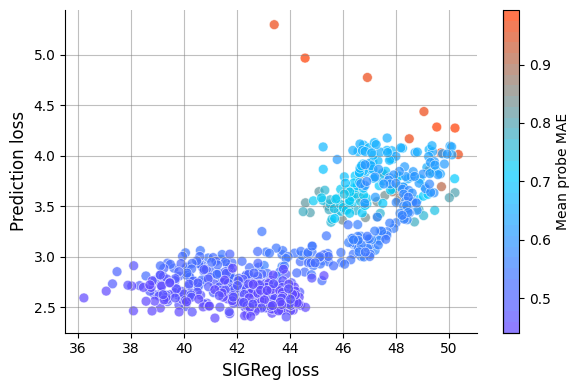

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from colors import bi_diverging_cmap

fig, ax = plt.subplots(figsize=(6, 4))

combined = combined[combined["SigReg Loss"] < 80]

sc = ax.scatter(
    combined["SigReg Loss"],
    combined["Pred Loss"],
    c=combined["Probe"],
    cmap=bi_diverging_cmap,
    s=50,
    alpha=0.7,
    edgecolors="white",
    linewidth=0.5,
)

ax.set_xlabel("SIGReg loss", fontsize=12)
ax.set_ylabel("Prediction loss", fontsize=12)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Mean probe MAE")
plt.tight_layout()
# Save with 300 dpi
ax.grid(axis="both", color="gray", linestyle="-", alpha=0.5)

# despine
sns.despine()

# save
plt.savefig("figures/loss_scatter_plot.png", dpi=300, bbox_inches="tight")

plt.show()


### Probe vs. train time

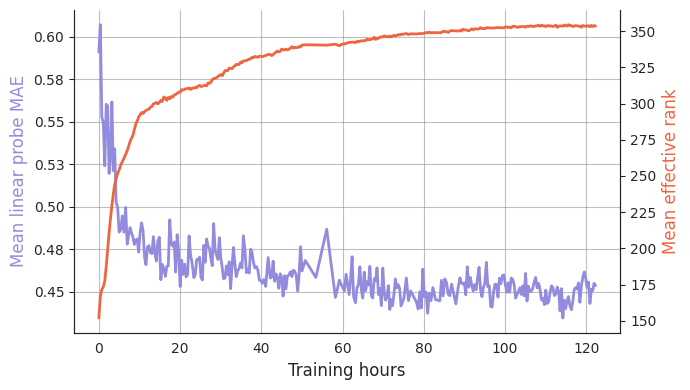

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df_probe = pd.read_csv("logs/performance/probe.csv")
df_rank = pd.read_csv("logs/performance/rank.csv")

COLORS = ["#928bde", "#ee6541"]

# add grid
sns.set_style("white")

# Convert wall-clock timestamps into elapsed training hours
df_probe = df_probe.sort_values("Wall time")
df_probe["train_hours"] = (df_probe["Wall time"] - df_probe["Wall time"].min()) / 3600.0

df_rank = df_rank.sort_values("Wall time")
df_rank["train_hours"] = (df_rank["Wall time"] - df_rank["Wall time"].min()) / 3600.0

fig, ax = plt.subplots(figsize=(7, 4))

# Left axis: linear probe MAE
sns.lineplot(data=df_probe, x="train_hours", y="Value", color=COLORS[0], ax=ax,
             linewidth=2, solid_capstyle="round")
ax.set_xlabel("Training hours", fontsize=12)
ax.set_ylabel("Mean linear probe MAE", color=COLORS[0], fontsize=12)
ax.tick_params(axis="y")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}"))

# Right axis: effective rank
ax2 = ax.twinx()
sns.lineplot(data=df_rank, x="train_hours", y="Value", color=COLORS[1], ax=ax2,
             linewidth=2, solid_capstyle="round")
sns.scatterplot(data=df_rank, x="train_hours", y="Value", color=COLORS[1], ax=ax2,
                linewidth=0.8, legend=False, s=0)
ax2.set_ylabel("Mean effective rank", color=COLORS[1], fontsize=12)
ax2.tick_params(axis="y")

# add one grid to ax
ax.grid(axis="both", color="gray", linestyle="-", alpha=0.5)

# despine but keep right
sns.despine(right=False, top=True)
plt.tight_layout()
plt.savefig("figures/probe_training_time_plot.png", dpi=300)
plt.show()


### Per modality losses

In [1]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CATEGORY_MAP = {
    "er": "Effective rank",
    "pred_loss": "Prediction loss",
    "sigreg_loss": "SIGReg loss",
}

records = []
for path in sorted(glob.glob("logs/multimodal/*.csv")):
    fname = os.path.splitext(os.path.basename(path))[0]
    category = next((k for k in CATEGORY_MAP if fname.startswith(k + "_")), None)
    if category is None:
        continue
    modality = fname[len(category) + 1:]
    df = pd.read_csv(path)
    df["category"] = CATEGORY_MAP[category]
    df["modality"] = modality
    records.append(df)

data = pd.concat(records, ignore_index=True)

t0 = data["Wall time"].min()
data["train_hours"] = (data["Wall time"] - t0) / 3600.0

def _norm(x):
    lo, hi = x.min(), x.max()
    return (x - lo) / (hi - lo) if hi > lo else x * 0.0

data["Value_norm"] = data.groupby(["category", "modality"])["Value"].transform(_norm)

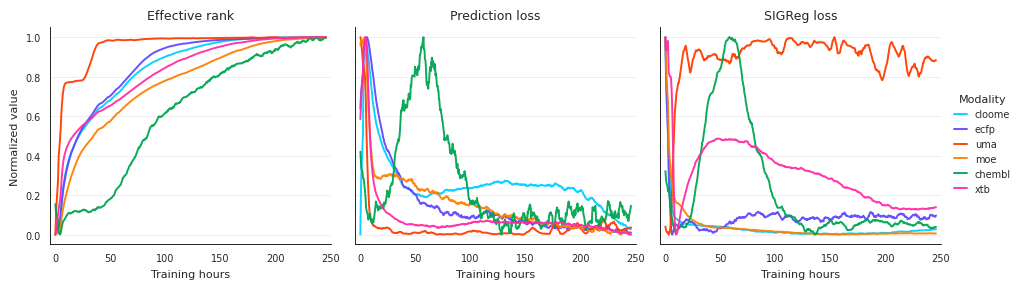

In [10]:
from colors import DISCRETE_COLORS_BRIGHT

sns.set_style("white")
categories = ["Effective rank", "Prediction loss", "SIGReg loss"]
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)

# Smooth first (on raw Value), then normalize the smoothed series to [0, 1].
SMOOTH_WINDOW = 10
data_smoothed = data.sort_values("train_hours").copy()
data_smoothed["Value_smooth_raw"] = (
    data_smoothed.groupby(["category", "modality"])["Value"]
    .transform(lambda s: s.rolling(SMOOTH_WINDOW, min_periods=1, center=True).mean())
)

def _norm(x):
    lo, hi = x.min(), x.max()
    return (x - lo) / (hi - lo) if hi > lo else x * 0.0

data_smoothed["Value_smooth"] = (
    data_smoothed.groupby(["category", "modality"])["Value_smooth_raw"].transform(_norm)
)

for ax, cat in zip(axes, categories):
    sub = data_smoothed[data_smoothed["category"] == cat]
    sns.lineplot(
        data=sub,
        x="train_hours",
        y="Value_smooth",
        hue="modality",
        ax=ax,
        linewidth=1.4,
        alpha=0.95,
        palette=sns.color_palette(DISCRETE_COLORS_BRIGHT),
    )
    ax.set_title(cat, fontsize=9)
    ax.set_xlabel("Training hours", fontsize=8)
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=7, length=3, width=0.6, color="black")
    ax.yaxis.grid(True, color="#ececec", linewidth=0.6)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    ax.margins(x=0.02)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("black")
        ax.spines[side].set_linewidth(0.6)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

axes[0].set_ylabel("Normalized value", fontsize=8)

# Single shared legend on the right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Modality",
    loc="center right",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=7,
    title_fontsize=8,
    handlelength=1.4,
    borderaxespad=0.0,
)

plt.tight_layout(rect=[0, 0, 0.97, 1])
plt.savefig("figures/per_modality_losses.png", dpi=300, bbox_inches="tight")
plt.show()
